In [190]:
import tpqoa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 30))
plt.style.use("seaborn-v0_8")



<Figure size 3000x3000 with 0 Axes>

In [ ]:
api = tpqoa.tpqoa('oanda.cfg')
api.get_account_summary()

In [ ]:
df = api.get_history('EUR_USD', '2024-01-01 00:00', '2025-12-30 23:00', 'H1', 'B')
df.info()

In [179]:
close = df.drop(columns=['o', 'l', 'h', 'complete', 'volume']).copy()

In [180]:
close.to_csv('eurusd1H.csv')

In [ ]:
sma_l = 20
sma_h = 50
close['SMA_20'] = close['c'].rolling(20).mean()
close['SMA_50'] = close['c'].rolling(50).mean()

new = close.dropna()

In [ ]:
new = close.dropna()



In [ ]:
# plt.plot(new)
new.loc['2025-10', ['c', 'SMA_20', 'SMA_50', 'direction']].plot(figsize=(50, 30), secondary_y='direction', title = 'EURUSD', fontsize=30)


In [184]:
new['direction'] = np.where(new['SMA_20'] > new['SMA_50'], 1, -1)

new.head()

,c,SMA_20,SMA_50,returns,direction
time,,,,,
2024-01-03 23:00:00,1.09253,1.092717,1.096068,NaN,-1
2024-01-04 00:00:00,1.09219,1.092518,1.095824,-0.000311,-1
2024-01-04 01:00:00,1.09172,1.092351,1.095587,-0.000430,-1
2024-01-04 02:00:00,1.09187,1.092153,1.095349,0.000137,-1
2024-01-04 03:00:00,1.09256,1.091983,1.095132,0.000632,-1


In [182]:
new['returns'] = np.log(new['c'].div(new['c'].shift(1)))
new.head()

,c,SMA_20,SMA_50,returns
time,,,,
2024-01-03 23:00:00,1.09253,1.092717,1.096068,NaN
2024-01-04 00:00:00,1.09219,1.092518,1.095824,-0.000311
2024-01-04 01:00:00,1.09172,1.092351,1.095587,-0.000430
2024-01-04 02:00:00,1.09187,1.092153,1.095349,0.000137
2024-01-04 03:00:00,1.09256,1.091983,1.095132,0.000632


In [ ]:
new.head(20)


In [185]:
new['strategy return'] = new['direction'].shift(1) * new['returns']

In [ ]:
new[['returns', 'strategy return']].sum()


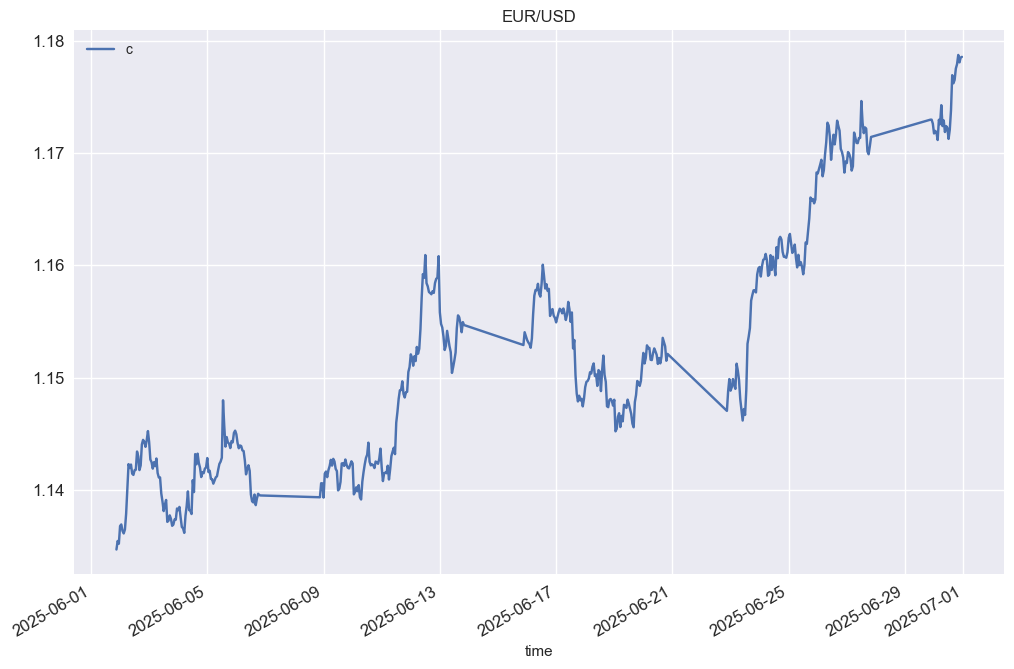

In [192]:
new.loc["2025-06", ['c']].plot(figsize = (12, 8), title = "EUR/USD", fontsize = 12)
plt.show()

# **Find the best strategy**

In [173]:
class BestSMA:
    def test(dataframes, sma):
        sma_s = sma[0]
        sma_b = sma[1]
        dataframe = dataframes.copy()
        dataframe['sma_s'] = dataframe['c'].rolling(sma[0]).mean()
        dataframe['sma_b'] = dataframe['c'].rolling(sma[1]).mean()
        dataframe.dropna()
        dataframe['returns'] = np.log(dataframe['c'].div(dataframe['c'].shift(1)))
        dataframe['direction'] = np.where(dataframe['sma_s'] > dataframe['sma_b'], 1, -1)
        dataframe['strategy_return'] = dataframe['direction'].shift(1) * dataframe['returns']
        # return np.exp(dataframe['strategy_return'].sum())
        return dataframe['strategy_return'].sum()



In [ ]:
BestSMA.test(dataframes=new, small=402,big= 1002)

In [ ]:
sma_s_range = range(10, 50, 1)
sma_b_range = range(100, 252, 1)

In [ ]:
from itertools import product


In [ ]:
combination = list(product(sma_s_range, sma_b_range))
combination

In [ ]:
len(combination)


In [174]:
result = []
for i in combination:
    result.append(BestSMA.test(new, i))

In [175]:
result


[np.float64(-0.054234605424399895),
 np.float64(-0.05938873959167608),
 np.float64(-0.0718155995956197),
 np.float64(-0.08642335145035132),
 np.float64(-0.08611528475524163),
 np.float64(-0.07664279602175306),
 np.float64(-0.08688961274387316),
 np.float64(-0.08287285546304939),
 np.float64(-0.07958079088210392),
 np.float64(-0.07782453936422537),
 np.float64(-0.07898637557667648),
 np.float64(-0.07995517522296303),
 np.float64(-0.07244635244460342),
 np.float64(-0.07415898989433031),
 np.float64(-0.09007442799329315),
 np.float64(-0.09246053022204369),
 np.float64(-0.09265530100258504),
 np.float64(-0.08671927098780623),
 np.float64(-0.09412632019431225),
 np.float64(-0.06662238704823709),
 np.float64(-0.07092978912934034),
 np.float64(-0.07006115289963144),
 np.float64(-0.0761371343290555),
 np.float64(-0.062094099393354314),
 np.float64(-0.06288225076561706),
 np.float64(-0.07096422059413722),
 np.float64(-0.07858934940347391),
 np.float64(-0.07960695970269581),
 np.float64(-0.07647

In [176]:
np.max(result)

np.float64(0.13169354390816418)

In [177]:
np.argmax(result)


np.int64(5303)

In [178]:
combination[np.argmax(result)]

(44, 235)